In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [147]:
data = pd.read_csv("../datasets/ads/Advertising.csv")
data_ads = data

In [148]:
data_ads.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [149]:
len(data_ads)

200

In [150]:
data_ads["corr_p"] = (data_ads["TV"] - np.mean(data_ads["TV"])) * (data_ads["Sales"] - np.mean(data_ads["Sales"]))

In [151]:
data_ads.head()

,TV,Radio,Newspaper,Sales,corr_p
0,230.1,37.8,69.2,22.1,670.896956
1,44.5,39.3,45.1,10.4,371.460206
2,17.2,45.9,69.3,9.3,613.181206
3,151.5,41.3,58.5,18.5,19.958456
4,180.8,10.8,58.4,12.9,-37.892794


In [152]:
data_ads["coor1"] = (data_ads["TV"] - np.mean(data_ads["TV"])) ** 2

In [153]:
data_ads.head()

,TV,Radio,Newspaper,Sales,corr_p,coor1
0,230.1,37.8,69.2,22.1,670.896956,6898.548306
1,44.5,39.3,45.1,10.4,371.460206,10514.964306
2,17.2,45.9,69.3,9.3,613.181206,16859.074806
3,151.5,41.3,58.5,18.5,19.958456,19.869306
4,180.8,10.8,58.4,12.9,-37.892794,1139.568806


In [154]:
data_ads["coor2"] = (data_ads["Sales"] - np.mean(data_ads["Sales"])) ** 2

In [155]:
data_ads.head()

,TV,Radio,Newspaper,Sales,corr_p,coor1,coor2
0,230.1,37.8,69.2,22.1,670.896956,6898.548306,65.246006
1,44.5,39.3,45.1,10.4,371.460206,10514.964306,13.122506
2,17.2,45.9,69.3,9.3,613.181206,16859.074806,22.302006
3,151.5,41.3,58.5,18.5,19.958456,19.869306,20.048006
4,180.8,10.8,58.4,12.9,-37.892794,1139.568806,1.260006


In [156]:
corr_p = sum(data_ads["corr_p"]) / np.sqrt(sum(data_ads["coor1"]) * sum(data_ads["coor2"]))

In [157]:
corr_p

0.782224424861606

In [158]:
def coor_coeff(df, var1, var2):
    df["corr_p"] = (df[var1] - np.mean(df[var1])) * (df[var2] - np.mean(df[var2]))
    df["coor1"] = (df[var1] - np.mean(df[var1])) ** 2
    df["coor2"] = (df[var2] - np.mean(df[var2])) ** 2
    corr_p = sum(df["corr_p"]) / np.sqrt(sum(df["coor1"]) * sum(df["coor2"]))
    return corr_p

In [159]:
coor_coeff(data_ads, "TV", "Sales")

0.782224424861606

In [160]:
cols = data.columns.values

In [161]:
cols

array(['TV', 'Radio', 'Newspaper', 'Sales', 'corr_p', 'coor1', 'coor2'],
      dtype=object)

In [162]:
for x in cols:
    for y in cols:
        print(x + ", " + y + " : " + str(coor_coeff(data,x ,y)))

TV, TV : 1.0
TV, Radio : 0.05480866446583009
TV, Newspaper : 0.056647874965056993
TV, Sales : 0.782224424861606
TV, corr_p : -0.0011216033233262073
TV, coor1 : -0.07879735036509569
TV, coor2 : -0.04435683271077501
Radio, TV : 0.05480866446583009
Radio, Radio : 1.0
Radio, Newspaper : 0.3541037507611752
Radio, Sales : 0.5762225745710553
Radio, corr_p : 0.003367194224496663
Radio, coor1 : 0.1085768694522202
Radio, coor2 : 0.28933391270094067
Newspaper, TV : 0.056647874965056993
Newspaper, Radio : 0.3541037507611752
Newspaper, Newspaper : 1.0
Newspaper, Sales : 0.22829902637616525
Newspaper, corr_p : 0.004654495262249754
Newspaper, coor1 : 0.5503385875778577
Newspaper, coor2 : 0.45100034081887913
Sales, TV : 0.782224424861606
Sales, Radio : 0.5762225745710553
Sales, Newspaper : 0.22829902637616525
Sales, Sales : 1.0
Sales, corr_p : 0.03435823617756815
Sales, coor1 : 0.3226857579432848
Sales, coor2 : 0.3391108854965276
corr_p, TV : 0.002251660616088983
corr_p, Radio : 0.013091062391317217
c

Text(0.5,1,'Gasto en TV vs Venta de productos')

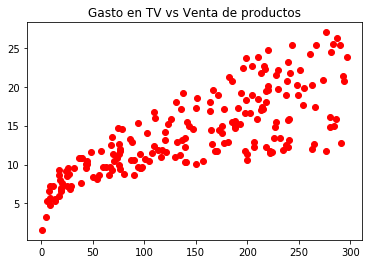

In [164]:
plt.plot(data_ads["TV"], data_ads["Sales"], "ro")
plt.title("Gasto en TV vs Venta de productos")

Text(0.5,1,'Gasto en Radio vs Venta de productos')

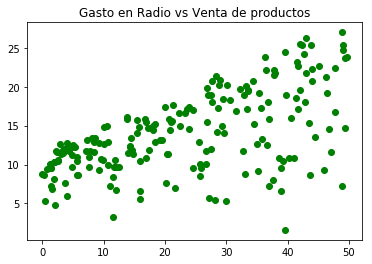

In [165]:
plt.plot(data_ads["Radio"], data_ads["Sales"], "go")
plt.title("Gasto en Radio vs Venta de productos")

Text(0.5,1,'Gasto en Newspaper vs Venta de productos')

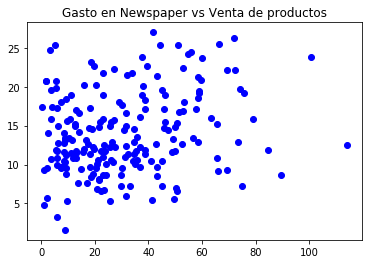

In [166]:
plt.plot(data_ads["Newspaper"], data_ads["Sales"], "bo")
plt.title("Gasto en Newspaper vs Venta de productos")

In [167]:
data = pd.read_csv("../datasets/ads/Advertising.csv")
data.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


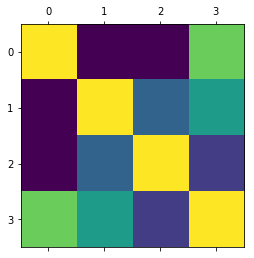

In [169]:
plt.matshow(data.corr())